# Lecture 13 (B12): Surrogates and Gaussian processes

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §9.1-9.2 (Deep surrogates), §9.3-9.6 (GPs and Bayesian active learning), §9.7 (Active subspaces), §9.8 (GP value-function iteration), §9.9 (Deep kernels), §9.10 (GPs among Bayesian cousins)  
**Notebook role:** core  
**Original live-course source:** `lectures/day7/code/06_Active_Subspace_10D.ipynb`  
**Course author:** Simon Scheidegger  
**License:** see repository `LICENSE` (MIT, code) and `LICENSE-content.md` (CC0 1.0, content).


In [ ]:
# Run-mode switch (smoke = CPU-bounded for CI, teaching = laptop figures, production = full reproduction).
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0


# Active Subspaces: 10D Example -- Eigenvalue Drop

*Companion notebook to **Day 7 — Surrogates, Gaussian Processes, Structural Estimation** (Chapters 9–10 of the lecture script).*

*Author: Simon Scheidegger (HEC Lausanne and Grantham Institute, LSE) — [course repository](https://github.com/sischei/Deep_Learning_for_Solving_And_Estimating_Dynamic_Economic_Models).*

This notebook demonstrates the active subspace method on a **10-dimensional** test function. Despite the high-dimensional input, the eigenvalue spectrum of the gradient covariance matrix $C_N$ reveals a **sharp drop after the first eigenvalue**, indicating that the function effectively lives on a **1D active subspace**. The corresponding eigenvector $W$ identifies dimension 2 as the dominant input direction.

**Reference:** Scheidegger & Bilionis (2019), *Machine Learning for High-Dimensional Dynamic Stochastic Economies*, Journal of Computational Science 33, 68--82.

**Corresponds to:** Figure 4 in the paper.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

plt.rcParams['font.size'] = 13

## 1. 10D Test Function

We define $f:\mathbb{R}^{10} \to \mathbb{R}$ as:

$$f(x) = \exp\!\bigl(0.01\,x_1 + 0.7\,x_2 + 0.02\,x_3 + 0.03\,x_4 + 0.04\,x_5 + 0.05\,x_6 + 0.06\,x_7 + 0.08\,x_8 + 0.09\,x_9 + 0.1\,x_{10}\bigr)$$

The coefficient on $x_2$ ($= 0.7$) is an order of magnitude larger than the others, so the function varies predominantly along dimension 2. The gradient is $\nabla f(x) = f(x)\cdot \mathbf{c}$ where $\mathbf{c} = (0.01, 0.7, 0.02, \ldots, 0.1)$.

In [2]:
def test_example(x):
    return np.exp(0.01*x[0] + 0.7*x[1] + 0.02*x[2] + 0.03*x[3] + 0.04*x[4] + 
                  0.05*x[5] + 0.06*x[6] + 0.08*x[7] + 0.09*x[8] + 0.1*x[9])

def dtest_example(x):
    val = test_example(x)
    coefs = np.array([0.01, 0.7, 0.02, 0.03, 0.04, 0.05, 0.06, 0.08, 0.09, 0.1])
    return val[:, None] * coefs[None, :]

# Random points on Omega = [-1,1]^D
def randOmega(N, D):
    "random points on \Omega = [-1,1]^D"
    return 2 * (np.random.rand(N, D) - 0.5)

## 2. Gradient Computation and $C_N$ Matrix

We sample $N = 300$ points in $[-1,1]^{10}$, evaluate the function and its gradient at each point, and form the **gradient covariance matrix**:

$$C_N = \frac{1}{N}\sum_{i=1}^{N}\nabla f(x_i)\,\nabla f(x_i)^\top \;\in\;\mathbb{R}^{10\times 10}.$$

This symmetric positive semi-definite matrix encodes how strongly $f$ varies along each direction in input space.

In [3]:
np.random.seed(41)
N = 300
X = randOmega(N, 10)
V = test_example(X.T)
G = dtest_example(X.T)
CN = (G.T @ G) / N

## 3. Eigenvalue Decomposition

We compute the eigenvalues $\lambda_1 \le \lambda_2 \le \ldots \le \lambda_{10}$ and eigenvectors of $C_N$. A **sharp drop** in the eigenvalue spectrum (a large gap between consecutive eigenvalues) signals that the function's variability is concentrated on a low-dimensional subspace. The eigenvector $W$ corresponding to the largest eigenvalue spans the 1D active subspace.

In [4]:
# Eigenvalue decomposition of the gradient covariance matrix
vals, vecs = linalg.eigh(CN)
W = vecs[:, -1]

print(f"Eigenvalues (ascending): {vals}")
print(f"Ratio lambda_10 / lambda_9: {vals[-1] / vals[-2]:.1f}x")

Eigenvalues (ascending): [-1.36331999e-18 -3.71981456e-19 -1.41514523e-19 -8.61961469e-21
  9.15610621e-35  1.77635960e-34  2.08594530e-18  9.88257049e-18
  1.11022302e-16  7.28576474e-01]
Ratio lambda_10 / lambda_9: 6562433471783063.0x


## 4. Visualization

**Left panel -- Eigenvalue spectrum:** The sharp drop after the largest eigenvalue confirms that a 1D active subspace captures nearly all of the function's variability. The remaining 9 eigenvalues are orders of magnitude smaller.

**Right panel -- Active subspace direction $W$:** The dominant eigenvector places almost all of its weight on dimension 2 (the input with coefficient $0.7$), correctly identifying it as the most important direction. The other dimensions receive negligible weight.

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(9, 5))
x = np.arange(1, 11)
ax[0].plot(x, vals, ".", ms=15)
ax[0].set_xlabel("Eigenvalues")
ax[0].set_xticks(x)
ax[0].set_ylabel(r"$\lambda$")

ax[1].plot(x, W, ".", ms=15)
ax[1].set_xlabel("Input dimension")
ax[1].set_xticks(x)
ax[1].set_ylabel("Magnitude of W")

fig.tight_layout()
plt.show()

## 5. ASGP vs.\ Full GP: Training-Set Size Sweep

To see why the 1D active subspace pays off, we compare two surrogates at several training-set sizes $N \in \{4, 8, 16, 32, 64\}$:

* **ASGP:** project the 10D input onto the 1D active subspace $Y = X W$ (with $W$ the leading eigenvector computed above) and fit a GP on the 1D data.
* **Full GP:** fit a GP directly on the 10D inputs.

Both are evaluated on a held-out test set of $1\,000$ points; we report the maximum absolute error.

/home/simon/.local/lib/python3.10/site-packages/sklearn/gaussian_process/_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


/home/simon/.local/lib/python3.10/site-packages/sklearn/gaussian_process/_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


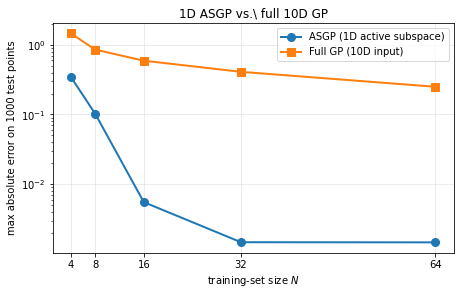

N =   4   ASGP err = 3.445e-01   full GP err = 1.454e+00   ratio = 4.2x
N =   8   ASGP err = 1.024e-01   full GP err = 8.526e-01   ratio = 8.3x
N =  16   ASGP err = 5.530e-03   full GP err = 5.912e-01   ratio = 106.9x
N =  32   ASGP err = 1.472e-03   full GP err = 4.092e-01   ratio = 278.0x
N =  64   ASGP err = 1.465e-03   full GP err = 2.499e-01   ratio = 170.5x


In [6]:
np.random.seed(0)
X_test  = randOmega(1000, 10)
f_test  = test_example(X_test.T)

Ns = [4, 8, 16, 32, 64]
err_asgp, err_fullgp = [], []

for N_i in Ns:
    X_tr = randOmega(N_i, 10)
    y_tr = test_example(X_tr.T)

    # ASGP on 1D projection using the precomputed W
    Y_tr   = (X_tr @ W).reshape(-1, 1)
    Y_test = (X_test @ W).reshape(-1, 1)
    gp_as  = GaussianProcessRegressor(RBF(), n_restarts_optimizer=2).fit(Y_tr, y_tr)
    err_asgp.append(float(np.max(np.abs(f_test - gp_as.predict(Y_test)))))

    # Full 10D GP
    gp_full = GaussianProcessRegressor(RBF(), n_restarts_optimizer=2).fit(X_tr, y_tr)
    err_fullgp.append(float(np.max(np.abs(f_test - gp_full.predict(X_test)))))

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.semilogy(Ns, err_asgp,  'o-', ms=8, lw=2, label='ASGP (1D active subspace)')
ax.semilogy(Ns, err_fullgp,'s-', ms=8, lw=2, label='Full GP (10D input)')
ax.set_xlabel('training-set size $N$')
ax.set_ylabel('max absolute error on 1000 test points')
ax.set_xticks(Ns)
ax.grid(True, alpha=0.3); ax.legend()
ax.set_title('1D ASGP vs.\\ full 10D GP')
plt.tight_layout(); plt.show()

for N_i, a, g in zip(Ns, err_asgp, err_fullgp):
    print(f'N = {N_i:3d}   ASGP err = {a:.3e}   full GP err = {g:.3e}   ratio = {g/a:.1f}x')


## 6. Read the Curves

The 1D ASGP already matches the true function to near-machine-precision with only a handful of points: it is solving a 1D regression problem, and the RBF kernel picks up the smooth 1D profile with as few as $N = 4$ training pairs.  The full-dimensional GP, in contrast, has to fit a 10D function and needs substantially more data to reach comparable accuracy.

This is the mechanism that lets GPs scale to $D = 100$ or more in Scheidegger & Bilionis (2019): identify the active subspace first, then fit the GP there.  Notebook `07_Active_Subspace_Nonlinear` is the follow-up on a target where $d = 1$ no longer suffices; notebooks `09` and `10` push further by replacing the *linear* projection with a learned nonlinear encoder.